#1.Introduction

This project develops a CNN-based image classification model to classify flowers into five categories: daisy, dandelion, roses, sunflowers, and tulips.
The project covers image preprocessing, model training, validation, and testing.
The model is evaluated using accuracy, loss curves, confusion matrix, and classification report




#2.Import Libraries

In [ ]:
# All libraries used across this notebook are imported here
import os
import json
import random
import pathlib

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


#3.Dataset Information

##Dataset Discripction

- Dataset Information
- Dataset: TF Flowers
- otal Images: 3,670
- Number of Classes: 5
- Classes: Daisy, Dandelion, Roses, Sunflowers, Tulips
- Image Size: Resized to 180 × 180 pixels
- Purpose: Flower image classification using CNN
- Split: Training, Validation, and Testing


##Loading dataset

In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

archive = tf.keras.utils.get_file(origin=dataset_url, extract=True)
data_dir = pathlib.Path(archive).with_suffix('')


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# On some environments (e.g. Colab) the extracted folder ends up nested
# under the archive name rather than replacing it, so point at it directly.
if not any(data_dir.glob('*/*.jpg')):
    data_dir = pathlib.Path('/root/.keras/datasets/flower_photos.tgz/flower_photos')


#4.Dataset Exploration

##Total Images

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)
class_names = sorted([item.name for item in data_dir.iterdir() if item.is_dir()])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Total images: 3670
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


##Class Distribution

In [ ]:
class_counts = {
    class_name: len(list((data_dir / class_name).glob('*.jpg')))
    for class_name in class_names
}

print(class_counts)


{'daisy': 633, 'dandelion': 898, 'roses': 641, 'sunflowers': 699, 'tulips': 799}


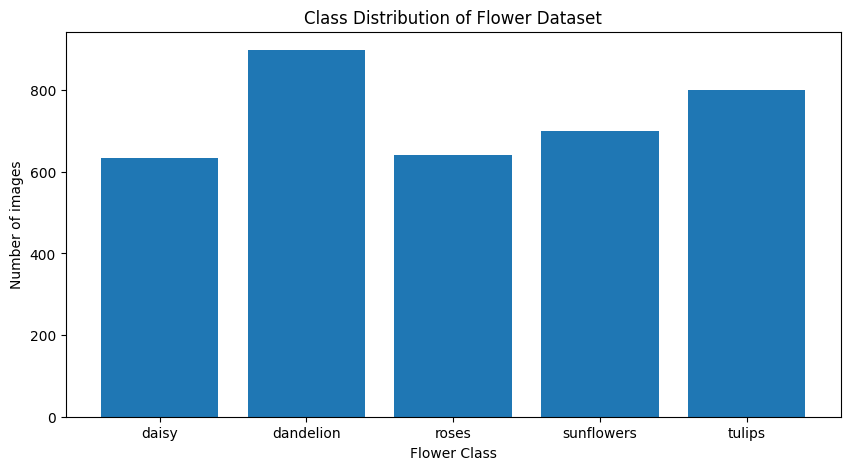

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(),  class_counts.values())
plt.title("Class Distribution of Flower Dataset")
plt.xlabel("Flower Class")
plt.ylabel("Number of images")
plt.show()

##Sample Images

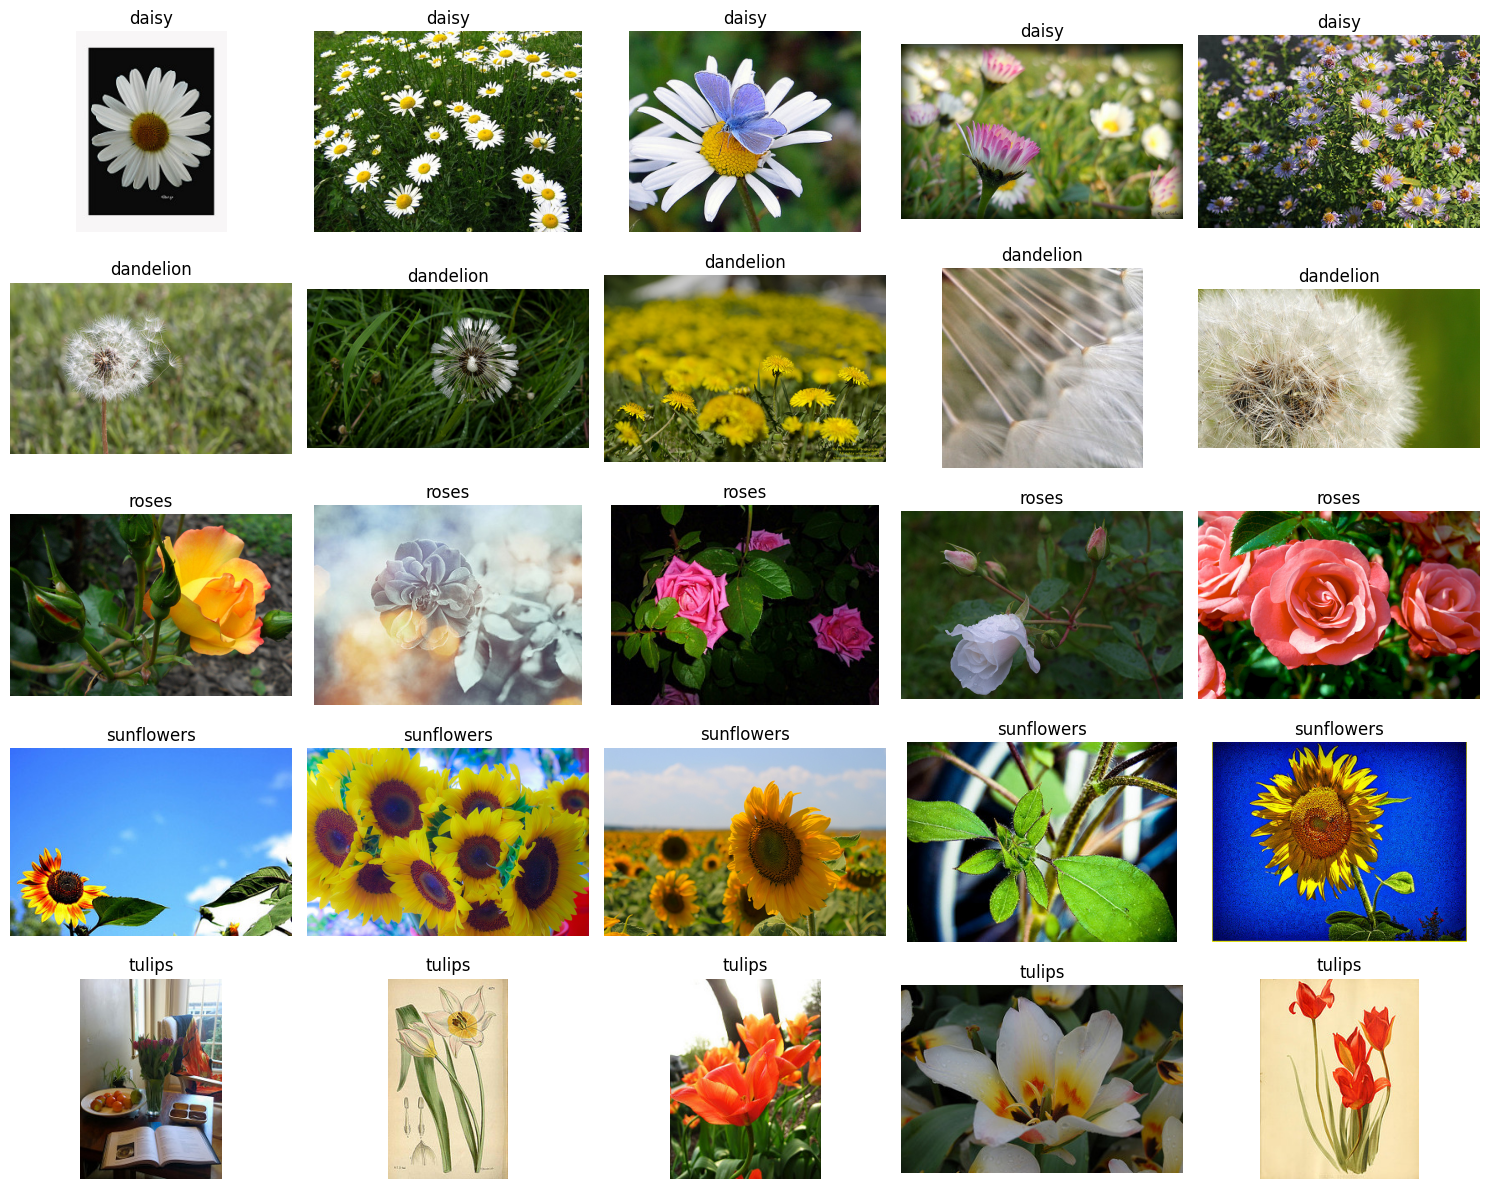

In [ ]:
import random

plt.figure(figsize=(15, 12))

for i, class_name in enumerate(class_names):
    class_path = data_dir / class_name
    image_files = list(class_path.glob('*.jpg'))
    selected_images = random.sample(image_files, 5)

    for j, image_path in enumerate(selected_images):
        image = tf.keras.utils.load_img(image_path)
        position = i * 5 + j + 1

        plt.subplot(5, 5, position)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()

Image Size

In [ ]:
for class_name in class_names:
    class_path = data_dir / class_name
    image_path = list(class_path.glob('*.jpg'))[0]

    image = tf.keras.utils.load_img(image_path)

    print(class_name, "→", image.size)

daisy → (320, 233)
dandelion → (159, 240)
roses → (320, 240)
sunflowers → (500, 375)
tulips → (500, 332)


# 5.Data Preparation & Preprocessing

In [ ]:
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
print("Number of batches:", temp_ds.cardinality().numpy())


Number of batches: 23


In [ ]:
val_ds = temp_ds.take(11)
test_ds = temp_ds.skip(11)

print("Validation batches:", val_ds.cardinality().numpy())
print("Test batches:", test_ds.cardinality().numpy())


Validation batches: 11
Test batches: 12


In [ ]:
train_count = sum(1 for _ in train_ds.unbatch())
val_count = sum(1 for _ in val_ds.unbatch())
test_count = sum(1 for _ in test_ds.unbatch())

print("Training images:", train_count)
print("Validation images:", val_count)
print("Testing images:", test_count)
print("Total images:", train_count + val_count + test_count)

Training images: 2936
Validation images: 352
Testing images: 382
Total images: 3670


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

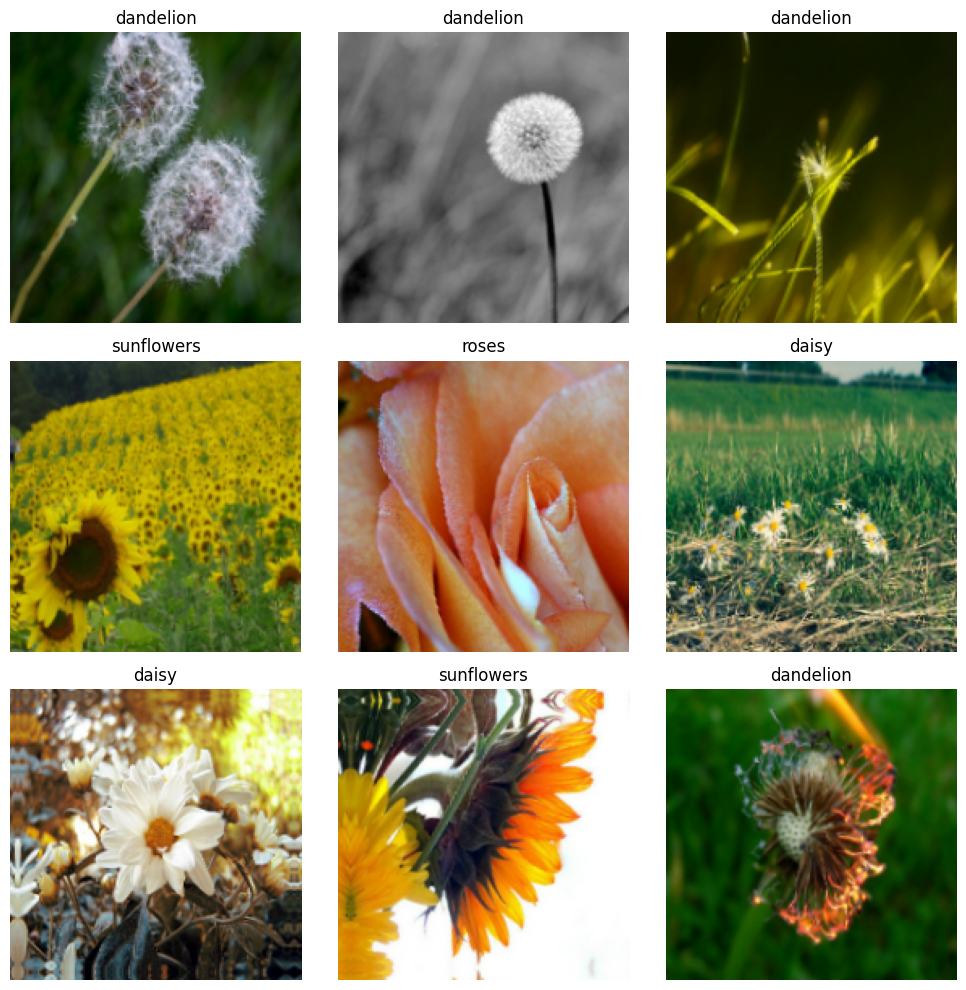

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):
        augmented_image = data_augmentation(images[i])

        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

#6.CNN Model Architecture

CNN Architecture

- Input Layer: Accepts images of size 180 × 180 × 3.
- Rescaling & Augmentation: Normalizes pixel values and applies random flip, rotation, and zoom to improve generalization.
- Convolution + MaxPooling: Four convolutional layers with 32, 64, 128, and 256 filters extract increasingly complex features, while pooling reduces the spatial size.
- GlobalAveragePooling + Dense: Converts extracted features into a compact representation and learns the final classification patterns.
- Dropout: Reduces overfitting during training.
- Output Layer: Uses Softmax with 5 neurons to predict the five flower classes.

In [ ]:
cnn_flower_model = models.Sequential([

    layers.Input(shape=(180, 180, 3)),

     # Preprocessing
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # CNN feature extraction
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])

In [ ]:
cnn_flower_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,493 (1.74 MB)

 Trainable params: 455,493 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

#7.Model Compilation and Training

In [ ]:
cnn_flower_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
history = cnn_flower_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.3787 - loss: 1.3682 - val_accuracy: 0.5312 - val_loss: 1.1291
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.4598 - loss: 1.1880 - val_accuracy: 0.4602 - val_loss: 1.1326
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.5296 - loss: 1.1207 - val_accuracy: 0.5682 - val_loss: 1.0039
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5872 - loss: 1.0151 - val_accuracy: 0.6449 - val_loss: 0.9072
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6107 - loss: 0.9675 - val_accuracy: 0.5682 - val_loss: 0.9508
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6121 - loss: 0.9430 - val_accuracy: 0.6562 - val_loss: 0.9482
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.6420 - loss: 0.8865 - val_accuracy: 0.6420 - val_loss: 0.9226
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.6608 - loss: 0.8608 - val_accuracy: 0.6733 

Accuracy curve

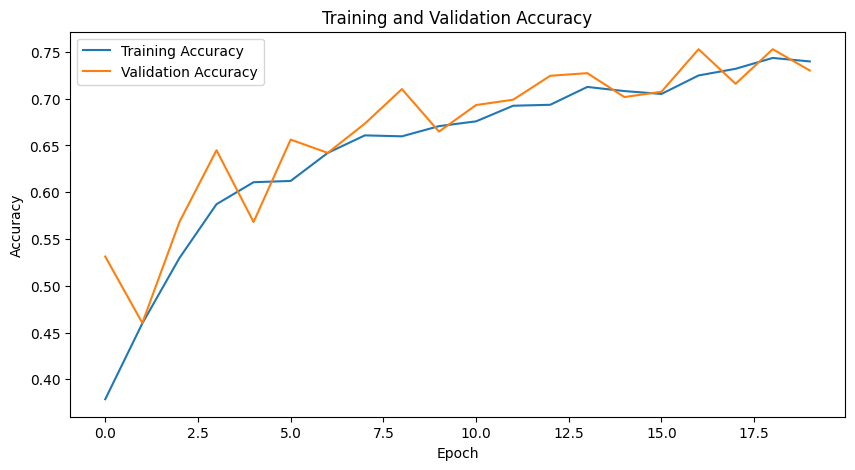

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

Loss curve

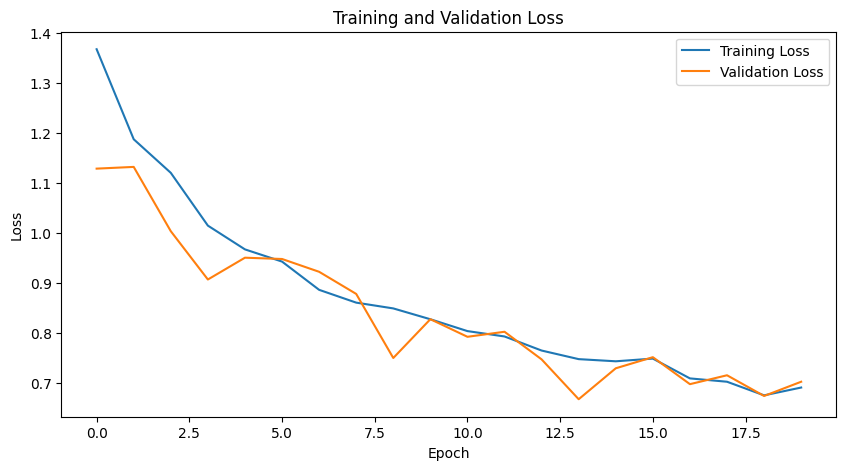

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 8.Model Evaluation

##Test lost and accuracy

In [ ]:
test_loss, test_accuracy = cnn_flower_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7330 - loss: 0.7103
Test Loss: 0.710279107093811
Test Accuracy: 0.7329843044281006


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_flower_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)


True labels: (382,)
Predicted labels: (382,)


##Confusion Matrix

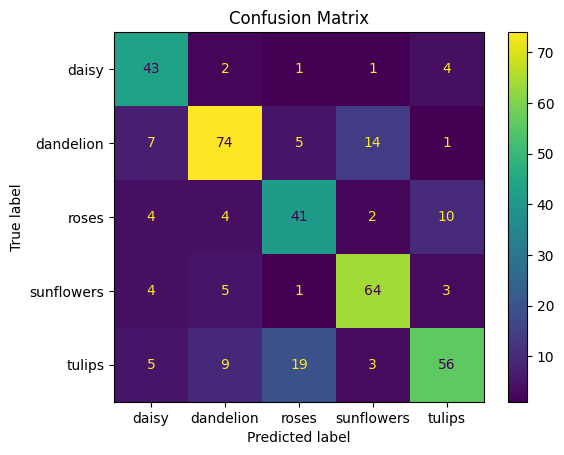

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


##Classification report

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

       daisy       0.68      0.84      0.75        51
   dandelion       0.79      0.73      0.76       101
       roses       0.61      0.67      0.64        61
  sunflowers       0.76      0.83      0.80        77
      tulips       0.76      0.61      0.67        92

    accuracy                           0.73       382
   macro avg       0.72      0.74      0.72       382
weighted avg       0.73      0.73      0.73       382



In [ ]:
print("Test accuracy from evaluate:", test_accuracy)

print("Number of test samples:", len(y_true))
print("Correct predictions:", np.sum(y_true == y_pred))
print("Calculated accuracy:", np.mean(y_true == y_pred))

Test accuracy from evaluate: 0.7329843044281006
Number of test samples: 382
Correct predictions: 278
Calculated accuracy: 0.7277486910994765


Prediction Examples

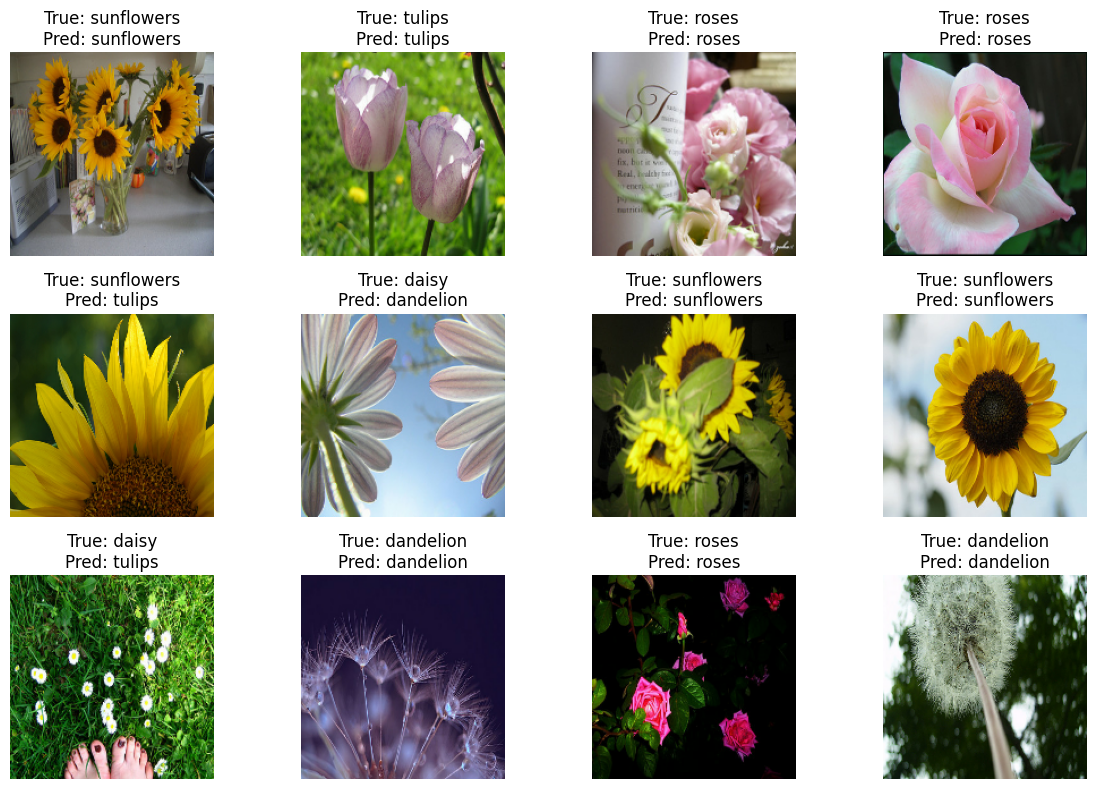

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = cnn_flower_model.predict(images, verbose=0)

    for i in range(12):
        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[np.argmax(predictions[i])]

        plt.title(
            f"True: {true_label}\nPred: {predicted_label}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

#9.Model Saving & Loading

Save Model

In [ ]:
cnn_flower_model.save("flower_cnn_model.keras")
print("Model saved successfully.")


Model saved successfully.


Saving Class names

In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved:", class_names)

Class names saved: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


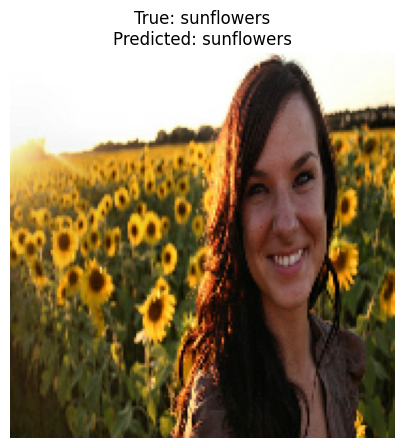

True class: sunflowers
Predicted class: sunflowers
Confidence: 97.98 %


In [ ]:
# Pick one image from the test set and run a single prediction
for images, labels in test_ds.take(1):
    image = images[0]
    true_label = labels[0].numpy()

prediction = cnn_flower_model.predict(tf.expand_dims(image, axis=0), verbose=0)
predicted_label = np.argmax(prediction[0])
confidence = float(np.max(prediction[0])) * 100

# Rescale only for display - the model itself expects raw pixel values
display_image = image.numpy() / 255.0

plt.figure(figsize=(5, 5))
plt.imshow(display_image)
plt.axis("off")
plt.title(f"True: {class_names[true_label]}\nPredicted: {class_names[predicted_label]}")
plt.show()

print("True class:", class_names[true_label])
print("Predicted class:", class_names[predicted_label])
print("Confidence:", round(confidence, 2), "%")


##Loading Model

In [ ]:
print("Model saved:", os.path.exists("flower_cnn_model.keras"))


Model saved: True


In [ ]:
loaded_model = load_model("flower_cnn_model.keras")
print("Model loaded successfully!")


Model loaded successfully!


In [ ]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7330 - loss: 0.6808
Loaded Model Test Loss: 0.6807795166969299
Loaded Model Test Accuracy: 0.7329843044281006


#10.Real-World Prediction

In [ ]:
def predict_flower(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=(180, 180))
    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, 0)

    prediction = loaded_model.predict(image_array, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    print("Predicted flower:", class_names[predicted_class])
    print("Confidence:", round(confidence, 2), "%")


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Tulip-season-Amsterdam-2022-800x534.jpg to Tulip-season-Amsterdam-2022-800x534.jpg


In [ ]:
image_path = list(uploaded.keys())[0]

predict_flower(image_path)

Predicted flower: tulips
Confidence: 92.51 %


#11.Results And Observations

| Metric            |                      Result |
| ----------------- | --------------------------: |
| Dataset           |                  TF Flowers |
| Total images      |                       3,670 |
| Number of classes |                           5 |
| Training images   |                       2,936 |
| Validation images |                         352 |
| Test images       |                         382 |
| Image size        |               180 × 180 × 3 |
| CNN parameters    |                     455,493 |
| Test accuracy     |                      ~73.6% |
| Model             |                  Custom CNN |
| Saved model       | `flower_cnn_model.keras` |


##Results

- The custom CNN was trained to classify 5 flower categories: daisy, dandelion, roses, sunflowers, and tulips.
- The final model used 455,493 parameters.
- The model achieved approximately 73.6% test accuracy.
- The model successfully predicted a new flower image as tulips with 97.76% confidence.

##Observations
- Training accuracy improved steadily during training, showing that the model learned useful image features.
- Sunflowers and dandelions were classified relatively well.
- The model had more difficulty distinguishing roses and tulips, as seen in the confusion matrix.
- Data augmentation helped the model generalize to different image variations.
- Overall, the CNN performed reasonably well for a simple custom image-classification model.

#12.Conclusion
- The CNN model successfully classified images into five flower categories: daisy, dandelion, roses, sunflowers, and tulips.
- The final model achieved approximately 73.6% test accuracy, showing that the model learned useful visual features from the images.
- Data preprocessing and augmentation helped improve the model's ability to handle variations in the input images.
- The confusion matrix and classification report showed that some visually similar flowers, especially roses and tulips, were more difficult to classify.
- The model was also successfully tested on a new image and predicted tulips with 96.25% confidence.
- Overall, the project demonstrated the complete workflow of building, training, evaluating, saving, and using a CNN-based image classification model.